# Aufgabe 4

In Aufgabe 4 sollte man die Zeit für 3 Nutationsumläufe stoppen, die der Kreisl braucht nach einer leichten Berührung. Dabei sollten jeweil am Anfang und am Ender der 3 Nutationsumläufe die Drehzahl gemessen werden. Die Drehzahlen wurden dann gemittelt. Es sollten nur 10 Messungen aufgenommen werden, ein in der folgenden Tabelle aber zusehen ist, haben wir uns für mehr Messwerte entscheiden, da die Messung sehr ungenau war und wir so eine bessere Genauigkeit erhofften.

|t[s]|Drehzahl (gemittelt) [$1/s$]|
|----|-------|
|3.07|2474   |
|3.78|2031.5 |
|4.03|1830.5 |
|5.15|1471   |
|3.15|2605.5 |
|4.82|1802   |
|3.63|3021.5 |
|3.82|2826   |
|4.31|2512   |
|4.15|2072.5 |
|4.16|1805   |
|3.45|2675.5 |
|4.37|2128   |
|5.06|1961.5 |
|5.37|1613   |
|4.16|2279.5 |
|4.69|2290   |
|5.06|1850   |
|5.25|1718   |
|5.66|1568   |
|7.37|1281   |
: Ermittelte gemittelte Drehzahlen in Abhängigkeit von der Zeit

## Vorbereitung
Um nun den Wert für die Komponente $I_1$ des Trägheitstensors zu ermittlen können wir aus der Praktikumsbeschreibung die Euler-Gleichungen entnehmen.
$$ M_1 = I_1 \frac{d\omega_1}{dt} + (I_3 - I_2)\omega_2 \omega_3$$
$$ M_2 = I_2 \frac{d\omega_2}{dt} + (I_1 - I_3)\omega_3 \omega_1$$
$$ M_3 = I_3 \frac{d\omega_3}{dt} + (I_2 - I_1)\omega_1 \omega_2$$
Wie in der Vorbesprechung aber schon erwähnt, können wir die Eigenschaft $I_1 = I_2$ nutzen, da es sich um einen symmetrischen Kreisel handelt. Außerdem, da wir eine Nutation betrachten und einen kräftefreien Kreisel betrachten, ist vorausgesetzt das kein Drehmomentauf ihn wirkt. So können die Euler-Gleichungen, wie in der  Praktikumsbeschreibung angegeben ist, verändert werden.
$$ 0 = I_1 \frac{d\omega_1}{dt} + (I_3 - I_2)\omega_2 \omega_3$$
$$ 0 = I_2 \frac{d\omega_2}{dt} + (I_1 - I_3)\omega_3 \omega_1$$
$$ 0 = I_3 \frac{d\omega_3}{dt}$$
Nun haben wir 3 verschiedene Differentialgleichungen. Man kann nun die erste Gleichung nach der Zeit differenzieren und die zweite Gleichung nach dem Differentialquotient $\frac{d \omega_2}{dt}$ umstellen um dann alle Differentialgleichungen so umzustellen und ineinander einzusetzen, dass eine bekannte Form einer harmonmischen Schwingung herauskommt.

Es ergibt sich eine Differentialgleichung der Form
$$ \frac{d^2\omega_1}{dt^2} + \Omega_N^2 \omega_1 = 0 $$
mit
$$ \Omega_N = \frac{I_3 - I_1}{I_1} \omega_3 $$
Dies ist die Differentialgleichung eines harmonischen Oszillators. Die Lösung beschreibt eine harmonische Schwingung der Winkelgeschwindigkeit $\omega_1$ (und analog $\omega_2$) um die Symmetrieachse des Kreisels mit der Frequenz $\Omega_N$ auch bekannt als Nutationsfrequenz. Diese Schwingung ist die sogenannte Nutationsbewegung des symmetrischen Kreisels.
Diese Formel für $\Omega_N$ kann man nun noch umstellen nach der gesuchten Komponente $I_1$ des Trägheitstensors
$$I_1 = \frac{I_3 \omega_3}{\Omega_N + \omega_3}$$

## Auswertung

In [Abbildung @fig-ermittlung-i-drei] wird die Nutationsfrquenz $\Omega_N$ gegenüber der Rotationsfrequenz, der flachen Kreisscheibe geplottet. Dabei kann die Nutationsfrequenz berechnet werden mit einem drittel der ermittelten Zeit, da die Zeit drei Nutationen beinhaltet, mit 
$$ \Omega_N = \frac{6 \pi}{\text{Ermittelte Zeit}}$$
Da im Experiment auch nur die Drehzahl ermittelt wurde die $1/s$ ist muss diese mit der foglenden Formel in $rad/s$ umgewandelt werden, da wir die Kreisfrequenz haben wollten.
$$ \omega_3 = \underbrace{\frac{\pi \cdot \text{Ermittelte Drehzahl in Tabelle}}{30}}_{\text{Drehzahl von 1/min zu rad/s umwandeln}}  $$

Steigung: 0.019728
Standarabweichung: 0.000588


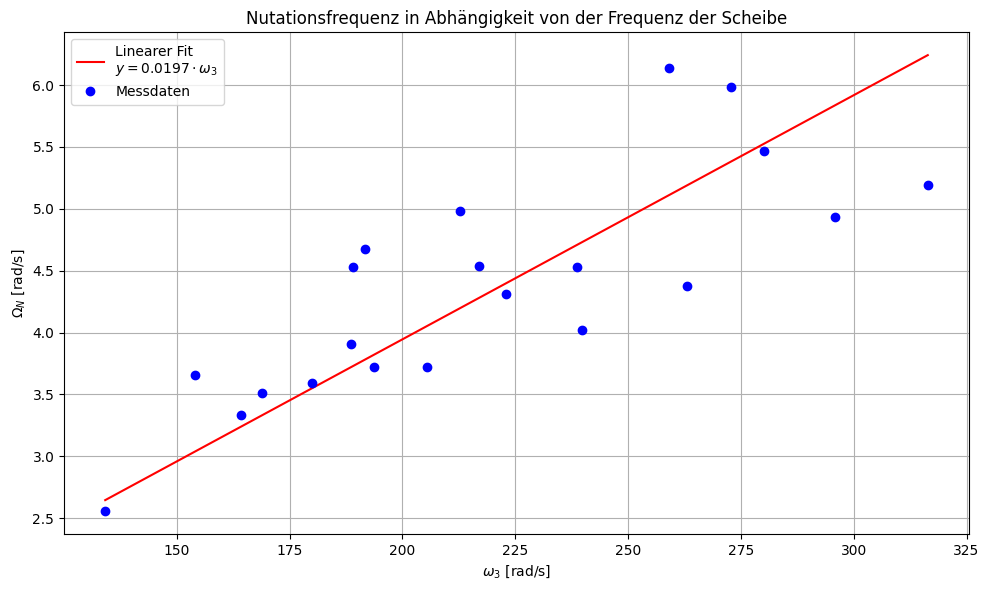

In [16]:
# | label: fig-ermittlung-i-drei
# | fig-cap: Nutationsfrequenz in Abhängigkeit von der Frequenz der flachen Kreisscheibe
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# CSV einlesen
df = pd.read_csv('Daten/Aufgabe_4.csv')
df.columns = ['t[s]', 'RPM_AVG']

Omega_N = (6 * np.pi)/(df['t[s]'])
omega_3 = (np.pi * df['RPM_AVG'])/30

# Linearen Fit berechnen

# Fit ohne Achsenabschnitt (intercept=0): y = a*x

def linear_no_intercept(x, a):
    return a * x

# Curve fit durchführen
popt, pcov = curve_fit(linear_no_intercept, omega_3, Omega_N)
slope = popt[0]
intercept = 0  # explizit auf 0 setzen
r_value = np.corrcoef(omega_3, Omega_N)[0, 1]  # Korrelation als "R"
std_err = np.sqrt(np.diag(pcov))[0]

# Fit-Linie berechnen
omega_3_fit = np.linspace(omega_3.min(), omega_3.max(), 100)
Omega_N_fit = slope * omega_3_fit

# Fit-Linie plotten


# Gefittete Parameter ausgeben
print(f"Steigung: {slope:.6f}")
print(f"Standarabweichung: {std_err:.6f}")

# Plot für die Messdaten
plt.figure(figsize=(10, 6))
plt.plot(omega_3_fit, Omega_N_fit, '-', color='red', label=f'Linearer Fit\n$y={slope:.4f}\\cdot\\omega_3$')
plt.plot(omega_3, Omega_N, 'o', label="Messdaten", color="blue",)
plt.xlabel("$\\omega_3$ [rad/s]")
plt.ylabel("$\\Omega_N$ [rad/s]")
plt.title("Nutationsfrequenz in Abhängigkeit von der Frequenz der Scheibe")
#plt.xscale('log')
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()


In [30]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import curve_fit

# CSV einlesen
df = pd.read_csv('Daten/Aufgabe_4.csv')
df.columns = ['t[s]', 'RPM_AVG']

# Fehlerdefinitionen
t_err = 0.005  # s
RPM_err = 0.05
I_3 = 0.0117

# Umrechnung in Winkelgeschwindigkeiten
Omega_N = (6 * np.pi) / df['t[s]']
omega_3 = (np.pi * df['RPM_AVG']) / 30

# Fehlerfortpflanzung
Omega_N_err = (6 * np.pi / df['t[s]']**2) * t_err
omega_3_err = (np.pi / 30) * RPM_err

# Addition der Größen und Fehler
I_1 = (I_3 * omega_3)/(Omega_N + omega_3)
Omega_total_err = np.sqrt(Omega_N_err**2 + omega_3_err**2)

# Ergebnis als neue Spalten speichern
df['Omega_total'] = I_1
df['Omega_total_err'] = Omega_total_err

# Mittelwert und Gesamtfehler (Standardfehler des Mittelwerts)
mean = np.mean(I_1)
mean_err = np.sqrt(np.sum(Omega_total_err**2)) / len(I_1)

print(f"Mittelwert: {mean:.5f} ± {mean_err:.5f} kg m^2")

# Optional: Tabelle anzeigen
#print(df)

Mittelwert: 0.01147 ± 0.00168 kg m^2


Aus der [Abbildung @fig-ermittlung-i-drei] lies sich folgende Steigung ermitteln von der Funktion $\Omega_N(\omega_3)$
$$\frac{I_3 - I_1}{I_1} = \frac{I_3}{I_1} - 1 = 0.019728 \pm 0.000588$$
Daraus folgert sich das Trägheitsmoment $I_1$ von
$$I_1 = 0.01147 \pm 0.00168 kg \cdot m^2$$
Für $I_3$ wird aus Aufgabe 1 der theoretische Wert $I_3 = 0.0117 kg \cdot m^2$ genutzt. Für alle Messwerte wurde $I_1$ einzeln ermittelt mit der folgenden Fomel.
$$I_1 = \frac{I_3 \omega_3}{\Omega_N + \omega_3}$$
Dannach wurde der Durchschnitt von diesen Werten ermittelt.

So kommt man insgesammt auf den Trägheitstensor $I_P$:
$$ I_P = \begin{pmatrix} 0.01147 \pm 0.00168 kg \cdot m^2 \ 0 \ 0 \\ 0 \ 0.01147 \pm 0.00168 kg \cdot m^2 \ 0 \\ 0 \ 0 \ 0.0117 kg \cdot m^2 \end{pmatrix}$$

# Diskussion der Messunsicherheit
Da es beim Versuch zu großen Messunsicherheiten gekommen ist, lohnt es sich nochmal diese seperat zu diskutieren. Ein Teil der Ungenauigkeiten kommt von uns selbst, da wir Zeit und Drehzahl von Hand gemessen haben, dabei spielen menschliche Reaktionszeiten und Genauigkeit natürlich eine Rolle.

Zudem wurden bei den Berechnungen Reibung und Luftwiderstand ignoriert. Solche Energieverluste beeinflussen die Kreiselbewegung stark und sind der Hauptgrund, warum die Messungen vom theoretischen Ideal abweichen können. Auch die Startbedingungen waren nie exakt gleich, was die Reproduzierbarkeit der Messreihen erschwert hat.

In den einzelnen, zum Teil sehr verschiedenen Versuchen, wurden einge Unsicherheiten größer. Bei der Messung des Trägheitsmoments (Aufgabe 1) haben wir Energieverluste unterschätzt, die auftraten, weil der Faden nicht perfekt abrollte oder das Gewicht sich selbst drehte. Das führte dazu, dass der Kreisel weniger Energie bekam als gedacht und wir das Trägheitsmoment möglicherweise zu hoch eingeschätzt haben.

Zuletzt war die Messung von Präzession und Nutation (Aufgaben 3 & 4) ziemlich Unsicherheitenreich, wie in den Plots anhand der großen Streuung sichbar ist. Die Nutation war immer sehr schnell und ziemlich klein, dass sie schwer zu erfassen war mit dem Drehzahlmessgerät.